# Laboratorio 10 - Obtención gráficas

**Integrantes:**

- Josue Say - 22801
- Flavio Galán - 22386

**Repositorio:**

- [Enlace GitHub](https://github.com/JosueSay/labs-ds/tree/main/lab2)

>**Nota:** Versión 3.12.3 de python

### Librerías

In [ ]:
import pandas as pd
import numpy as np
# import pyreadr
import matplotlib.pyplot as plt
import statsmodels.tsa as tsa
import statsmodels as sm
from datetime import datetime
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from pmdarima.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tabulate import tabulate
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from keras.layers import Dropout

### Variables - constantes

In [3]:
DATA_DIR = "../data"
IMAGE_DIR = "./images"
REPORTES = "./reportes"
CACHE = "./cache"

# output files
CONSUMO_CSV = f"{DATA_DIR}/consumo_combustibles.csv"
IMPORT_CSV = f"{DATA_DIR}/importacion_combustibles.csv"
PRECIOS_CSV = f"{DATA_DIR}/precios_diarios.csv"
TARGET_COLUMNS = ["fecha", "regular", "superior", "diesel", "glp"]
SHOW_RESULTS_LAB1 = True # Cambiar para ver las graficas y comparacion de metricas
SHOW_DL_S1 = True # Cambiar para ver las graficas de DL serie combustible regular y metricas
SAVE_IMAGES = True

os.makedirs(IMAGE_DIR, exist_ok=True)

### Obtención de data

In [4]:
def loadAllData():
    df_consumo = pd.read_csv(CONSUMO_CSV, parse_dates=["fecha"])
    df_importaciones = pd.read_csv(IMPORT_CSV, parse_dates=["fecha"])
    df_precios = pd.read_csv(PRECIOS_CSV, parse_dates=["fecha"])

    df_consumo = df_consumo.set_index("fecha")
    df_importaciones = df_importaciones.set_index("fecha")
    df_precios = df_precios.set_index("fecha")

    print("Datos cargados desde cache CSV.")
    return df_consumo, df_importaciones, df_precios

In [5]:
df_consumo, df_importaciones, df_precios = loadAllData()

Datos cargados desde cache CSV.


### Funciones graficadoras

In [6]:
def plotSeries(df, column, title, save=False, path=None):
    plt.figure(figsize=(10, 5))
    df[column].plot()
    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("Precio")
    plt.grid(True)
    plt.tight_layout()
    
    if save and path:
        plt.savefig(path)
    
    plt.show()

In [7]:
def plotAutocorrelations(series, 
                         title_acf="Autocorrelation (ACF)", 
                         title_pacf="Partial Autocorrelation (PACF)", 
                         figsize=(10,5), 
                         save=False, 
                         path_acf=None, 
                         path_pacf=None):
    
    # Gráfico ACF
    plt.figure(figsize=figsize)
    ax_acf = plt.gca()
    plot_acf(series, ax=ax_acf)
    plt.title(title_acf)
    plt.xlabel("Lag (días de desfase)")
    plt.ylabel("Relación (correlación entre precio actual y pasado)")
    plt.tight_layout()
    if save and path_acf:
        plt.savefig(path_acf)
    plt.show()
    
    # Gráfico PACF
    plt.figure(figsize=figsize)
    ax_pacf = plt.gca()
    plot_pacf(series, ax=ax_pacf)
    plt.title(title_pacf)
    plt.xlabel("Lag (días de desfase)")
    plt.ylabel("Relación (correlación parcial)")
    plt.tight_layout()
    if save and path_pacf:
        plt.savefig(path_pacf)
    plt.show()

In [ ]:
def decomposeSeries(series, column, title, save=False, path=None):
    s = series[column].copy()
    s.name = ""

    result = seasonal_decompose(s)
    fig = result.plot()
    fig.set_size_inches(15, 8)

    fig.suptitle(title, fontsize=16)

    plt.tight_layout()
    if save and path:
        plt.savefig(path)

    plt.show()

In [9]:
def plotResiduals(model, titulo):
    residuals = model.resid[1:]
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de residuales
    residuals.plot(ax=ax[0])
    ax[0].set_title("Residuales")
    ax[0].set_xlabel("Fecha")
    ax[0].set_ylabel("Valor residual")

    # Gráfico de densidad
    residuals.plot(kind="kde", ax=ax[1])
    ax[1].set_title("Densidad")
    ax[1].set_xlabel("Valor residual")
    ax[1].set_ylabel("Densidad")

    # Título general
    fig.suptitle(titulo, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### Funciones auxiliares para preparación/ejecución de data

In [10]:
def splitSeriesByYears(series, train_until="2023", val_year="2024", test_year="2025"):
    
    train = series[:f"{train_until}-12-31"]
    val = series[f"{val_year}-01-01":f"{val_year}-12-31"]
    test = series[f"{test_year}-01-01":]

    return train, val, test

In [11]:
def getRangeSerie(serie, initial_range, column, get_diff):
    df = serie[initial_range:]
    df = df[column]
    
    if get_diff:
        return df.diff().fillna(0)
    
    return df

In [12]:
def dickeyFullerTest(series, title="Dickey-Fuller Test"):
    print(f"===== {title} =====\n")
    
    dfTest = adfuller(series, autolag='AIC')
    
    # Resultados principales
    results = {
        "Test Statistic": dfTest[0],
        "p-value": dfTest[1],
        "Lags Used": dfTest[2],
        "N Observations": dfTest[3]
    }
    
    # Valores críticos
    critical_values = dfTest[4]
    
    # Crear tabla
    table_data = []
    for key, value in results.items():
        table_data.append([key, value])
    for key, value in critical_values.items():
        table_data.append([f"Critical Value ({key})", value])
    
    print(tabulate(table_data, headers=["Métrica", "Valor"], tablefmt="fancy_grid"))
    print("\n===== Fin del Test =====")

In [13]:
def convertToSupervised(series, nLags=1):
    x, y = [], []
    for i in range(len(series) - nLags):
        x.append(series[i:i + nLags, 0])
        y.append(series[i + nLags, 0])
    return np.array(x), np.array(y)

In [14]:
def trainARIMAModels(trainData):
    models = [
        ARIMA(trainData, order=(1,1,1)),
        ARIMA(trainData, order=(0,1,1)),
        ARIMA(trainData, order=(1,1,0))
    ]
    return [model.fit() for model in models]

In [15]:
def runMLPModel(train_scaled, val_scaled, test_scaled, scaler, n_lags=5, save=False, path=None, reshape_x_test = False):
    x_train, y_train = convertToSupervised(train_scaled, n_lags)
    x_val, y_val = convertToSupervised(val_scaled, n_lags)
    x_test, y_test = convertToSupervised(test_scaled, n_lags)

    model = MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=1
    )

    print("X TEST:", x_test)
    print("X TEST SHAPE:", np.shape(x_test))
    model.fit(x_train, y_train)
    if reshape_x_test:
        pred_test = model.predict(x_test.reshape(1, -1))
    else:
        pred_test = model.predict(x_test)

    # Invertir escalado
    pred_inv = scaler.inverse_transform(pred_test.reshape(-1, 1))
    actual_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Cálculo de métricas
    rmse = np.sqrt(mean_squared_error(actual_inv, pred_inv))
    mae = mean_absolute_error(actual_inv, pred_inv)

    # Gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(actual_inv, label='Real', color='blue')
    plt.plot(pred_inv, label='Predicción', linestyle='--', color='orange')
    plt.title("Predicción con MLP (Periodo de Test)")
    plt.xlabel("Tiempo")
    plt.ylabel("Precio")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save and path:
        plt.savefig(f"{path}/mlp_forecast.png")
    plt.show()

    return {
        "MLP": {
            "RMSE": rmse,
            "MAE": mae
        }
    }

In [16]:
def evaluateARIMAModels(models, testData, save=False, path=None):
    newDF = pd.DataFrame({'Original': testData})

    preds_111 = models[0].forecast(len(testData))
    preds_011 = models[1].forecast(len(testData))
    preds_110 = models[2].forecast(len(testData))
    preds_auto = pm.auto_arima(models[0].data.endog, seasonal=False).predict(len(testData))

    newDF = newDF.assign(
        Model_1_1_1=preds_111,
        Model_0_1_1=preds_011,
        Model_1_1_0=preds_110,
        Model_auto=preds_auto
    )

    newDF.plot(figsize=(10, 5))
    plt.title("ARIMA Model Predictions")
    plt.grid(True)
    plt.tight_layout()

    if save and path:
        plt.savefig(path)

    plt.show()

    return {
        "ARIMA(1,1,1)": preds_111,
        "ARIMA(0,1,1)": preds_011,
        "ARIMA(1,1,0)": preds_110,
        "ARIMA Auto": preds_auto
    }

In [17]:
def runProphetModel(trainData, testData=None, periods=365, save=False, path=None):
    df_train = pd.DataFrame({"ds": trainData.index, "y": list(trainData)})
    
    model = Prophet()
    model.fit(df_train)
    
    # Definir fechas futuras según test
    if testData is not None:
        future = pd.DataFrame({
            "ds": pd.date_range(
                start=trainData.index[0],
                end=testData.index[-1],
                freq="D"
            )
        })
    else:
        future = model.make_future_dataframe(periods=periods)
    
    forecast = model.predict(future)

    # Graficar solo periodo de test si se da
    if testData is not None:
        forecast_series = forecast.set_index("ds")["yhat"]
        forecast_trim = forecast_series.loc[testData.index]

        plt.figure(figsize=(10, 5))
        testData.plot(label="Real", color="blue")
        forecast_trim.plot(label="Predicción", color="orange", linestyle="--")
        plt.title("Predicción con Prophet (Periodo de Test)")
        plt.xlabel("Fecha")
        plt.ylabel("Precio")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        if save and path:
            plt.savefig(f"{path}/prophet_forecast.png")
        plt.show()
    else:
        fig1 = model.plot(forecast)
        plt.title("Predicción con Prophet")
        plt.xlabel("Fecha")
        plt.ylabel("Precio")
        plt.grid(True)
        plt.tight_layout()
        if save and path:
            fig1.savefig(f"{path}/prophet_forecast.png")
        plt.show()

    # Componentes
    fig2 = model.plot_components(forecast)
    plt.tight_layout()
    if save and path:
        fig2.savefig(f"{path}/prophet_components.png")
    plt.show()

    # Métricas con retorno unificado
    results = {}
    if testData is not None:
        forecast_series = forecast.set_index("ds")["yhat"]
        common_dates = testData.index.intersection(forecast_series.index)
        if len(common_dates) > 0:
            y_true = testData.loc[common_dates]
            y_pred = forecast_series.loc[common_dates]
            results["Prophet"] = {
                "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
                "MAE": mean_absolute_error(y_true, y_pred)
            }
        else:
            results["Prophet"] = {"RMSE": None, "MAE": None}
    else:
        results["Prophet"] = {"RMSE": None, "MAE": None}

    return forecast, model, results

In [18]:
def runHoltWintersModel(trainData, testData=None, forecast_steps=None, save=False, path=None):
    # Determinar pasos a predecir
    if testData is not None:
        steps = len(testData)
    else:
        steps = forecast_steps if forecast_steps is not None else 30

    # Ajustar modelo
    model = ExponentialSmoothing(
        trainData,
        trend='add',
        seasonal='add',
        seasonal_periods=12
    )
    fit = model.fit()
    predictions = fit.forecast(steps)

    # Corregir índice del pronóstico
    if testData is not None:
        predictions.index = testData.index
    else:
        last_date = trainData.index[-1]
        predictions.index = pd.date_range(
            start=last_date + pd.Timedelta(days=1),
            periods=steps,
            freq='D'
        )

    # Gráfico solo del periodo de test si aplica
    plt.figure(figsize=(10, 5))
    if testData is not None:
        testData.plot(label="Real", color="blue")
        predictions.plot(label="Pronóstico", linestyle="--", color="orange")
        plt.title("Predicción con Holt-Winters (Periodo de Test)")
    else:
        trainData.plot(label="Entrenamiento")
        predictions.plot(label="Pronóstico", linestyle="--")
        plt.title("Predicción con Holt-Winters")

    plt.xlabel("Fecha")
    plt.ylabel("Precio")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if save and path:
        plt.savefig(f"{path}/holtwinters_forecast.png")
    plt.show()

    # Métricas estructuradas como dict por nombre de modelo
    results = {}
    if testData is not None:
        common_dates = testData.index.intersection(predictions.index)
        if len(common_dates) > 0:
            y_true = testData.loc[common_dates]
            y_pred = predictions.loc[common_dates]
            results["Holt-Winters"] = {
                "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
                "MAE": mean_absolute_error(y_true, y_pred)
            }
        else:
            results["Holt-Winters"] = {"RMSE": None, "MAE": None}
    else:
        results["Holt-Winters"] = {"RMSE": None, "MAE": None}

    return predictions, fit, results

In [19]:
def convertARIMAPredictionsToMetrics(predictions_dict, true_values):
    metrics = {}
    for model_name, preds in predictions_dict.items():
        rmse = np.sqrt(mean_squared_error(true_values, preds))
        mae = mean_absolute_error(true_values, preds)
        metrics[model_name] = {
            "RMSE": rmse,
            "MAE": mae
        }
    return metrics

In [20]:
def mergeDisplayMetrics(arima_metrics, arima_values, mlp_metrics, prophet_metrics, hw_metrics, dl_metrics):
    metrics = convertARIMAPredictionsToMetrics(arima_metrics, arima_values)

    all_metrics = {
        "MLP": mlp_metrics.get("MLP", mlp_metrics),
        "Prophet": prophet_metrics.get("Prophet", prophet_metrics),
        "Holt-Winters": hw_metrics.get("Holt-Winters", hw_metrics),
        **metrics
    }

    if dl_metrics is not None:
        all_metrics.update(dl_metrics)

    # Crear la tabla
    table = tabulate(
        [[model, values["RMSE"], values["MAE"]] for model, values in all_metrics.items()],
        headers=["Modelo", "RMSE", "MAE"],
        tablefmt="fancy_grid"
    )

    # Imprimir la tabla
    print(table)

    # Guardar en archivo
    with open("metrics.txt", "w", encoding="utf-8") as f:
        f.write(table)

### Modelos

In [21]:
def preprocessLSTM(series):
    """Aplica diferenciación y escalado"""
    diff = series.diff().fillna(0)
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(diff.to_frame())
    return diff, scaled, scaler

In [22]:
def seriesToSupervisedLSTM(scaledSeries, n_lags=5):
    """Convierte serie a formato supervisado para LSTM"""
    x, y = [], []
    for i in range(len(scaledSeries) - n_lags):
        x.append(scaledSeries[i:i+n_lags])
        y.append(scaledSeries[i+n_lags])
    x = np.array(x).reshape(-1, n_lags, 1)
    y = np.array(y)
    return x, y

In [23]:
def splitSupervisedLSTMByYears(scaledSeries, index, train_until="2023", val_year="2024", test_year="2025", n_lags=5):
    index = pd.to_datetime(index)

    # Crear rangos por año
    train_mask = index <= f"{train_until}-12-31"
    val_mask = (index >= f"{val_year}-01-01") & (index <= f"{val_year}-12-31")
    test_mask = index >= f"{test_year}-01-01"

    # Seleccionar subconjuntos
    train = scaledSeries[train_mask]
    val = scaledSeries[val_mask]
    test = scaledSeries[test_mask]

    # Convertir a formato supervisado
    x_train, y_train = seriesToSupervisedLSTM(train, n_lags)
    x_val, y_val = seriesToSupervisedLSTM(val, n_lags)
    x_test, y_test = seriesToSupervisedLSTM(test, n_lags)

    return x_train, y_train, x_val, y_val, x_test, y_test

In [24]:
def buildLSTMModel1(n_lags, units=32, optimizer='adam'):
    """Construye el modelo LSTM simple con hiperparámetros"""
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(n_lags, 1)))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=optimizer)
    return model

In [25]:
def buildLSTMModel2(n_lags, units=64, dropout_rate=0.2, optimizer='adam'):
    """Construye un modelo LSTM más profundo con Dropout"""
    model = Sequential()
    model.add(LSTM(units=units, return_sequences=True, input_shape=(n_lags, 1)))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units=units))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=optimizer)
    return model

In [26]:
def trainAndEvaluateLSTM(x_train, y_train, x_val, y_val, x_test, y_test,
                         model, scaler, original_series, n_lags,
                         epochs=30, batch_size=32, name_model="LSTM Modelo 1",
                         metrics_dict=None, save=False, path=None):

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        verbose=0
    )

    # Gráfica de pérdida
    plt.figure()
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title("LSTM Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    y_pred_scaled = model.predict(x_test)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test)

    original = original_series[-(len(y_test_inv) + n_lags):].values
    y_pred_final = y_pred.flatten() + original[n_lags:]
    y_test_final = y_test_inv.flatten() + original[n_lags:]

    # Evaluación
    rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
    mae = mean_absolute_error(y_test_final, y_pred_final)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")

    if metrics_dict is not None:
        metrics_dict[name_model] = {"RMSE": rmse, "MAE": mae}

    # Gráfica de predicción
    fechas = original_series[-len(y_test_final):].index
    plt.figure(figsize=(10, 5))
    plt.plot(fechas, y_test_final, label="Real", color="blue")
    plt.plot(fechas, y_pred_final, label="Predicción", linestyle="--", color="orange")
    plt.xlabel("Fecha")
    plt.ylabel("Precio")
    plt.title(name_model)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save and path:
        filename = name_model.replace(" ", "_").replace(",", "").replace(":", "").replace("–", "-") + ".png"
        plt.savefig(f"{path}/{filename}")

    plt.show()

    return rmse, mae

## Modelos LSTM para serie de "Consumos de Diesel"

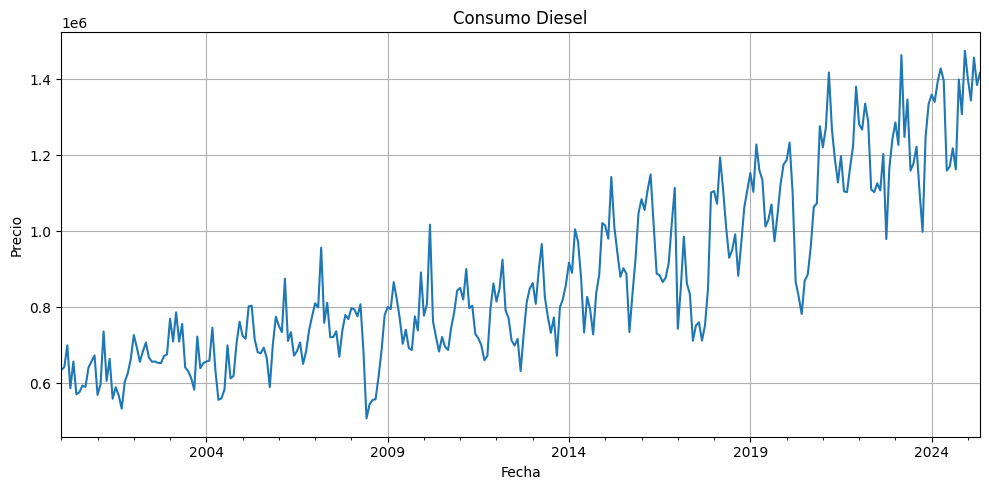

In [27]:
if SHOW_RESULTS_LAB1:
    plotSeries(df_consumo, column="diesel", title="Consumo Diesel", save=True, path=IMAGE_DIR + "/consumo_diesel.png")

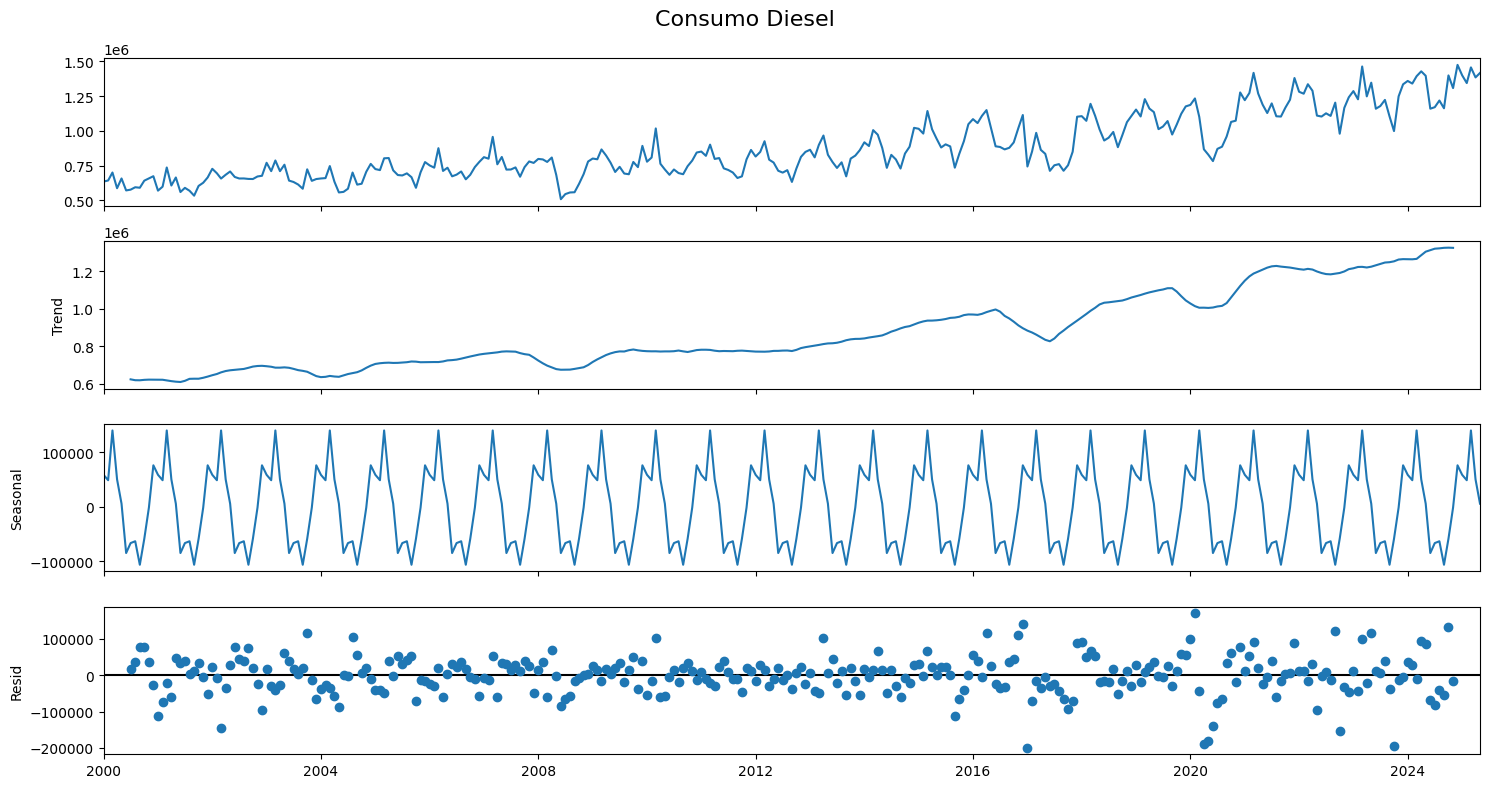

In [28]:
if SHOW_RESULTS_LAB1:
    decomposeSeries(df_consumo, column="diesel", title="Consumo Diesel", save=True, path=IMAGE_DIR + "/descomposition_diesel.png")

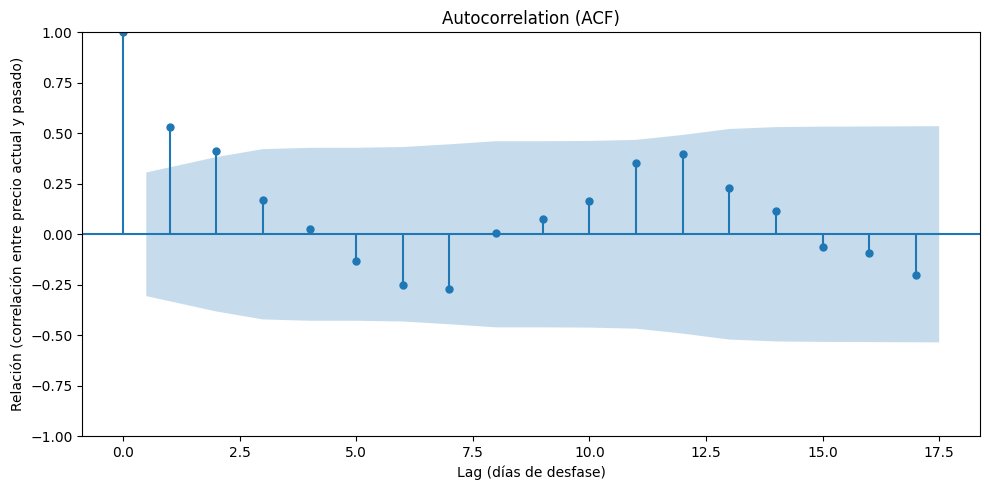

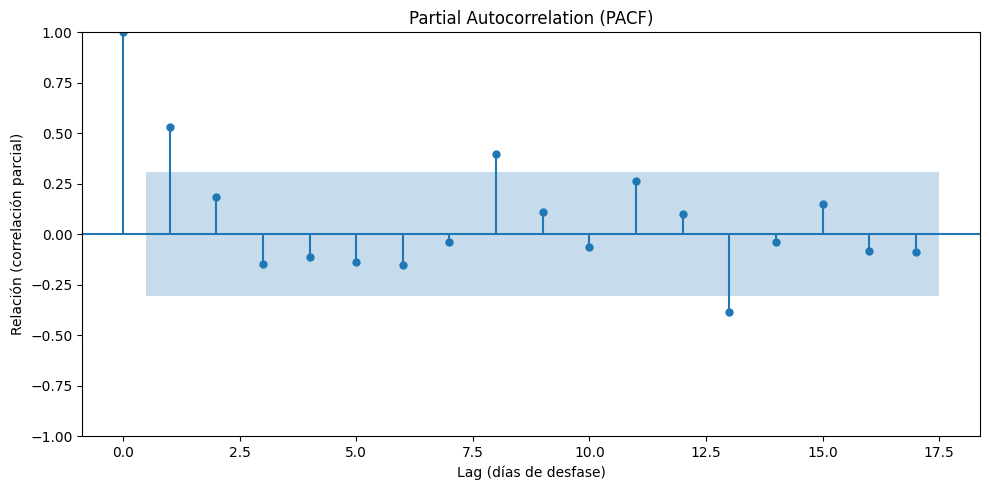

In [29]:
if SHOW_RESULTS_LAB1:
  df = getRangeSerie(serie=df_consumo, initial_range="2022", column="diesel", get_diff=False)
  plotAutocorrelations(df, save=SAVE_IMAGES,
                      path_acf=IMAGE_DIR + "/acf_diesel.png",
                      path_pacf=IMAGE_DIR + "/pacf_diesel.png")

In [30]:
if SHOW_RESULTS_LAB1:
    df = getRangeSerie(serie=df_consumo, initial_range="2022", column="diesel", get_diff=False)
    # Prueba sobre la serie original
    dickeyFullerTest(df, 
                     title="Prueba Dickey-Fuller - Serie Original (Consumo Diesel)")

===== Prueba Dickey-Fuller - Serie Original (Consumo Diesel) =====

╒══════════════════════╤═══════════╕
│ Métrica              │     Valor │
╞══════════════════════╪═══════════╡
│ Test Statistic       │ -0.167383 │
├──────────────────────┼───────────┤
│ p-value              │  0.942299 │
├──────────────────────┼───────────┤
│ Lags Used            │ 10        │
├──────────────────────┼───────────┤
│ N Observations       │ 30        │
├──────────────────────┼───────────┤
│ Critical Value (1%)  │ -3.66992  │
├──────────────────────┼───────────┤
│ Critical Value (5%)  │ -2.96407  │
├──────────────────────┼───────────┤
│ Critical Value (10%) │ -2.62117  │
╘══════════════════════╧═══════════╛

===== Fin del Test =====


In [31]:
if SHOW_RESULTS_LAB1:
    # Prueba sobre la serie diferenciada
    df = getRangeSerie(serie=df_consumo, initial_range="2022", column="diesel", get_diff=True)
    dickeyFullerTest(df, 
                     title="Prueba Dickey-Fuller - Serie Diferenciada (Consumo Diesel)")

===== Prueba Dickey-Fuller - Serie Diferenciada (Consumo Diesel) =====

╒══════════════════════╤══════════════╕
│ Métrica              │        Valor │
╞══════════════════════╪══════════════╡
│ Test Statistic       │ -4.65666     │
├──────────────────────┼──────────────┤
│ p-value              │  0.000101428 │
├──────────────────────┼──────────────┤
│ Lags Used            │ 10           │
├──────────────────────┼──────────────┤
│ N Observations       │ 30           │
├──────────────────────┼──────────────┤
│ Critical Value (1%)  │ -3.66992     │
├──────────────────────┼──────────────┤
│ Critical Value (5%)  │ -2.96407     │
├──────────────────────┼──────────────┤
│ Critical Value (10%) │ -2.62117     │
╘══════════════════════╧══════════════╛

===== Fin del Test =====


### Preparando la serie

In [32]:
df_rango = df_consumo["diesel"]["2022":].asfreq("D").ffill()
ts_diff, ts_scaled, scaler = preprocessLSTM(df_rango)
x_train, y_train, x_val, y_val, x_test, y_test = splitSupervisedLSTMByYears(
    scaledSeries=ts_scaled,
    index=df_rango.index,
    train_until="2023",
    val_year="2024",
    test_year="2025",
    n_lags=5
)

#### Hiperparámetros

In [33]:
param_grid = [
    {"units": 32, "batch_size": 16, "epochs": 30, "optimizer": "adam"},
    {"units": 64, "batch_size": 32, "epochs": 50, "optimizer": "adam"},
    {"units": 64, "batch_size": 16, "epochs": 40, "optimizer": "rmsprop"},
    {"units": 128, "batch_size": 32, "epochs": 60, "optimizer": "adam"},
]
param_grid_model2 = [
    {"units": 32, "batch_size": 16, "epochs": 30, "optimizer": "adam", "dropout": 0.2},
    {"units": 64, "batch_size": 32, "epochs": 50, "optimizer": "adam", "dropout": 0.3},
    {"units": 64, "batch_size": 16, "epochs": 40, "optimizer": "rmsprop", "dropout": 0.25},
    {"units": 128, "batch_size": 32, "epochs": 60, "optimizer": "adam", "dropout": 0.2},
]

#### Tuneando el modelo


=== Modelo 1 ===
Units: 32, Batch: 16, Epochs: 30, Optimizer: adam


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


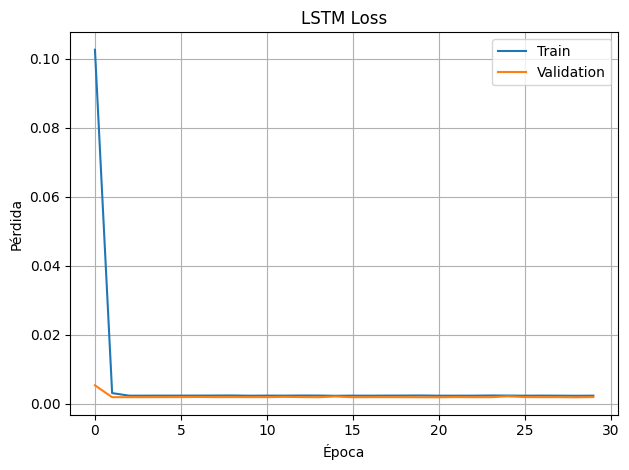

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
RMSE: 14799.3254
MAE: 7188.5174


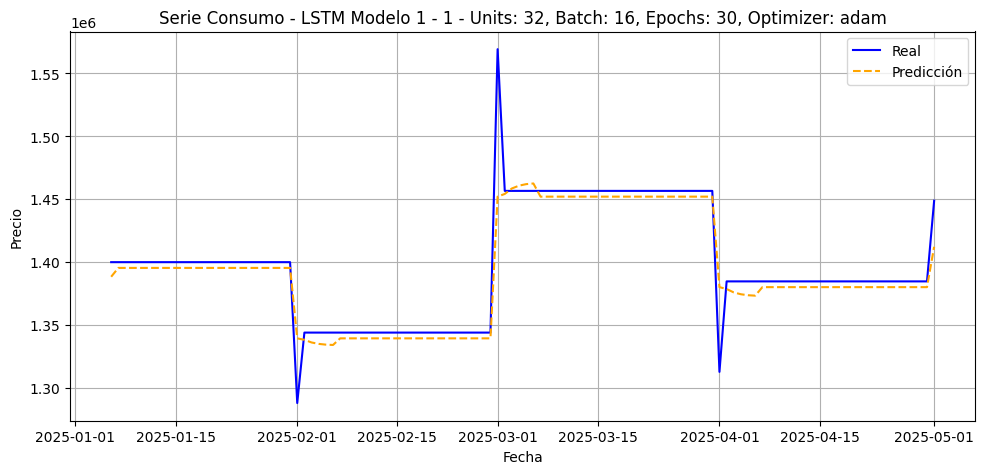


=== Modelo 2 ===
Units: 64, Batch: 32, Epochs: 50, Optimizer: adam


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


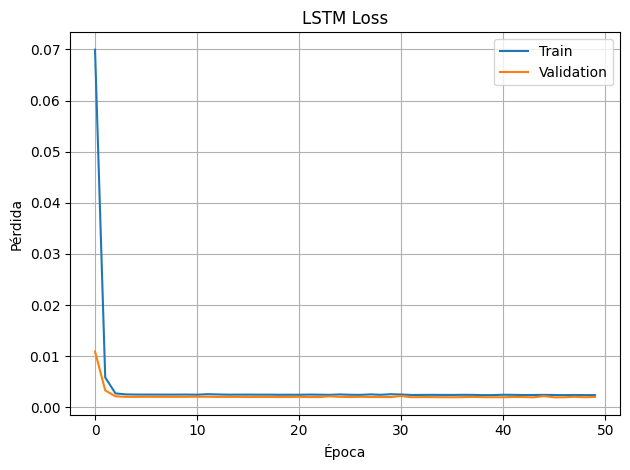

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
RMSE: 14807.8941
MAE: 7171.6586


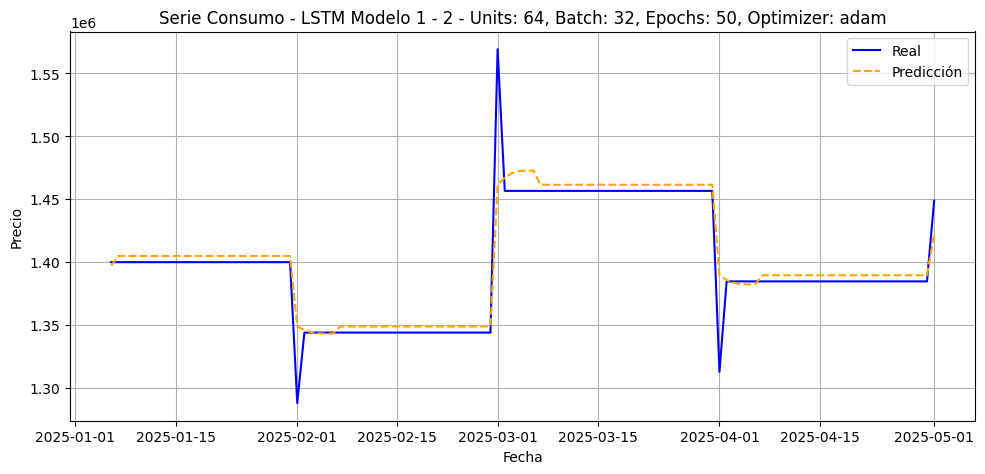


=== Modelo 3 ===
Units: 64, Batch: 16, Epochs: 40, Optimizer: rmsprop


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


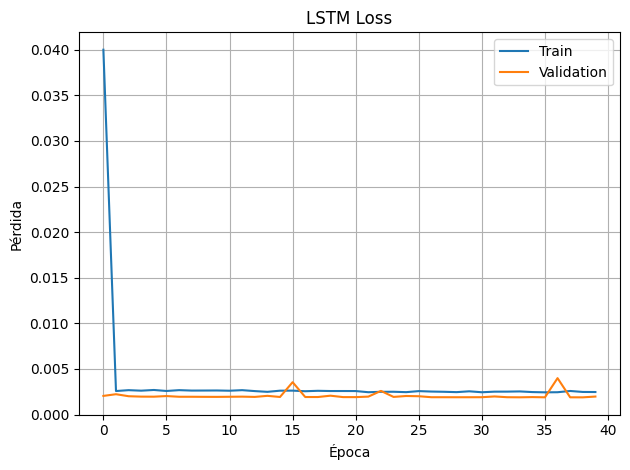

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000266AA6D0A40> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
RMSE: 14628.2922
MAE: 6777.3606


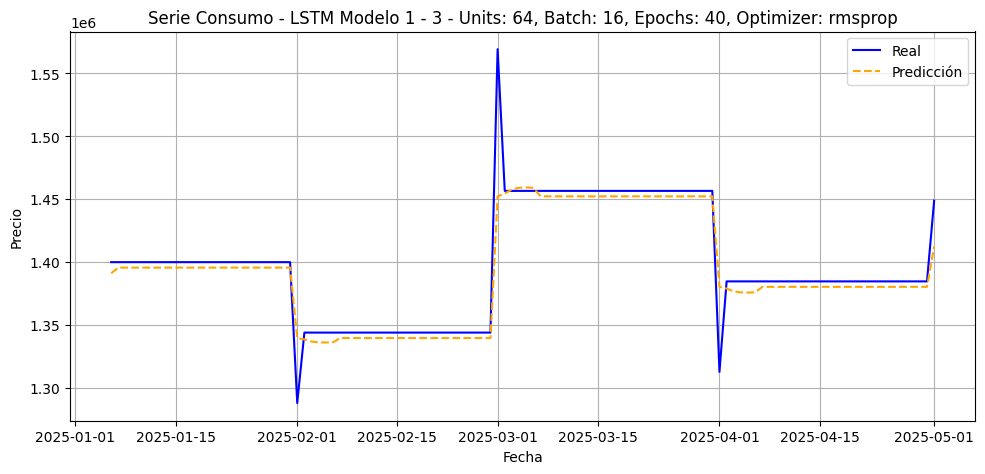


=== Modelo 4 ===
Units: 128, Batch: 32, Epochs: 60, Optimizer: adam


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


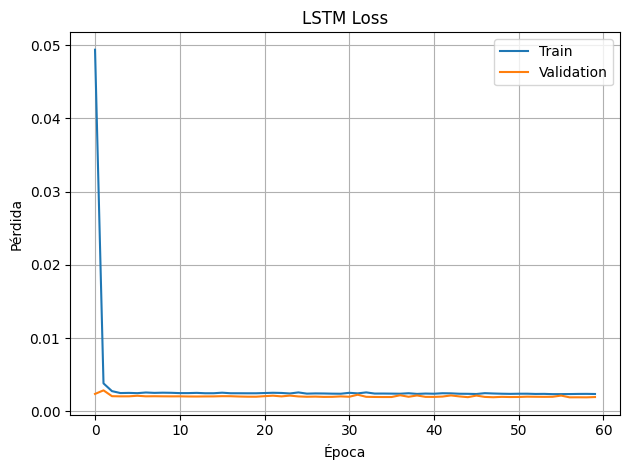

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
RMSE: 14307.4407
MAE: 5727.7532


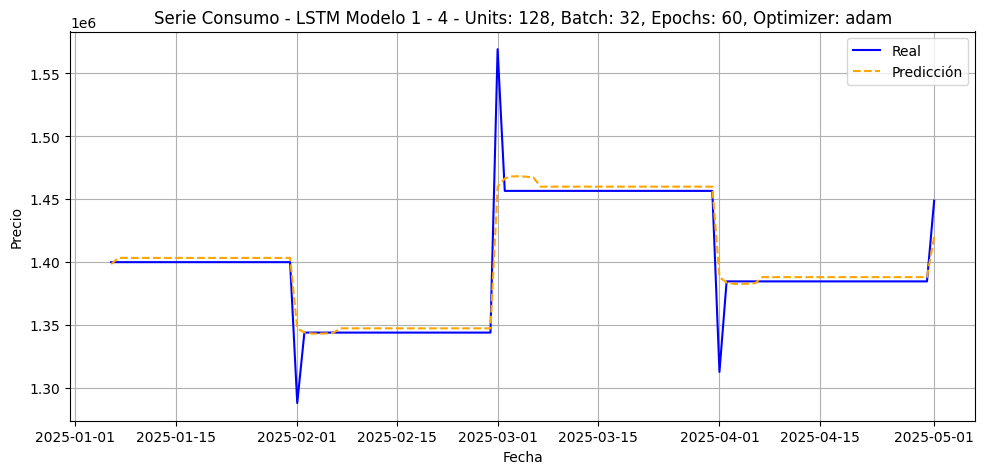


=== Modelo LSTM 2 - Configuración 1 ===
Units: 32, Batch: 16, Epochs: 30, Optimizer: adam, Dropout: 0.2


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


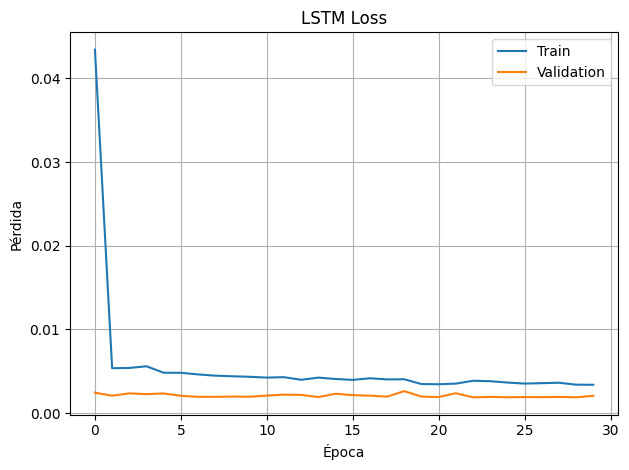

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
RMSE: 15388.1900
MAE: 8695.5648


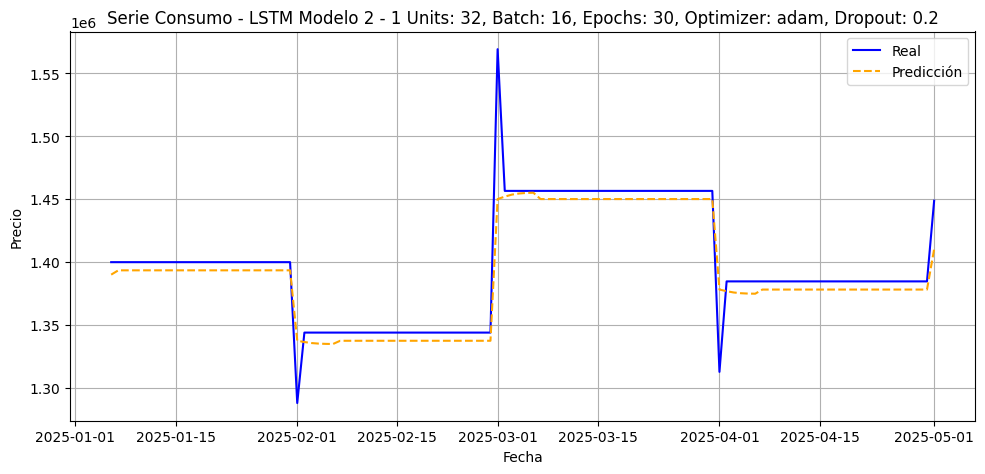


=== Modelo LSTM 2 - Configuración 2 ===
Units: 64, Batch: 32, Epochs: 50, Optimizer: adam, Dropout: 0.3


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


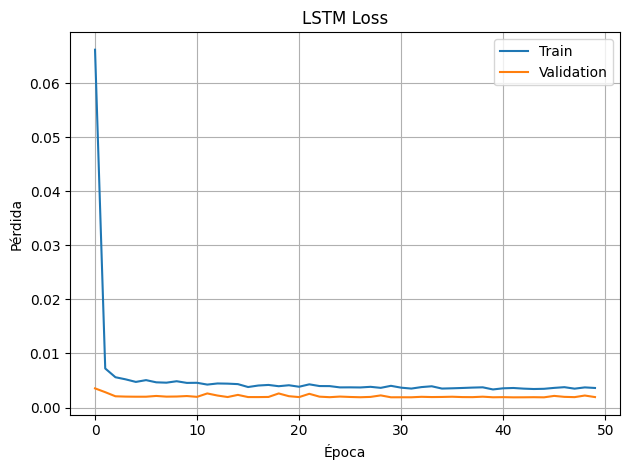

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
RMSE: 14389.6858
MAE: 6264.6438


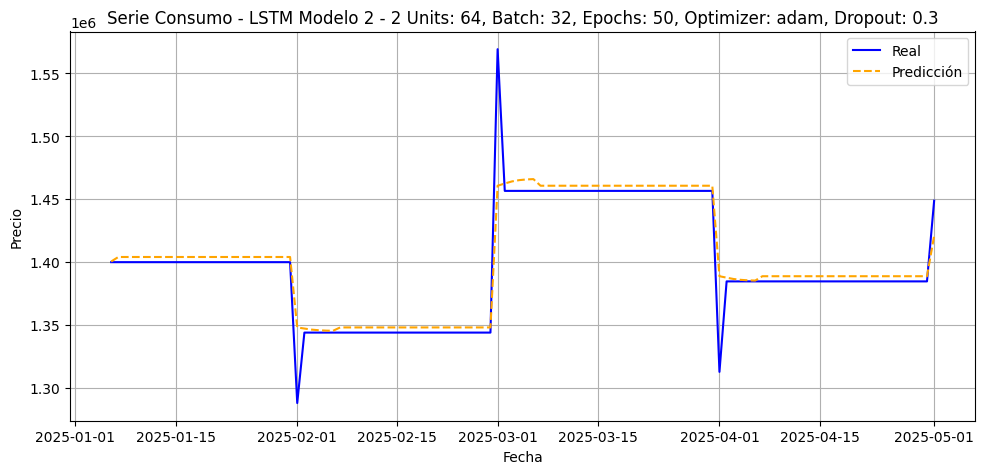


=== Modelo LSTM 2 - Configuración 3 ===
Units: 64, Batch: 16, Epochs: 40, Optimizer: rmsprop, Dropout: 0.25


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


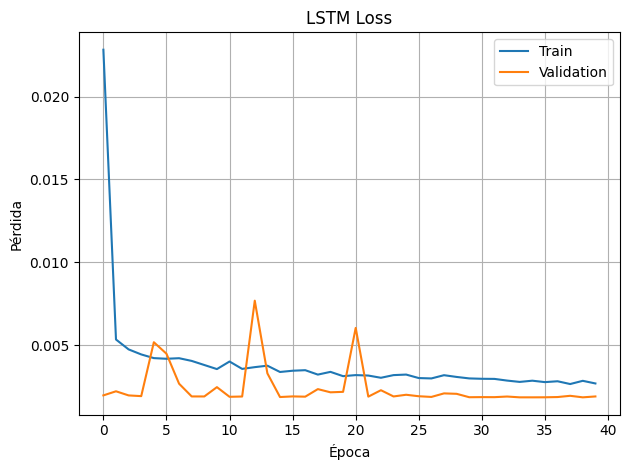

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
RMSE: 14223.5097
MAE: 5532.3346


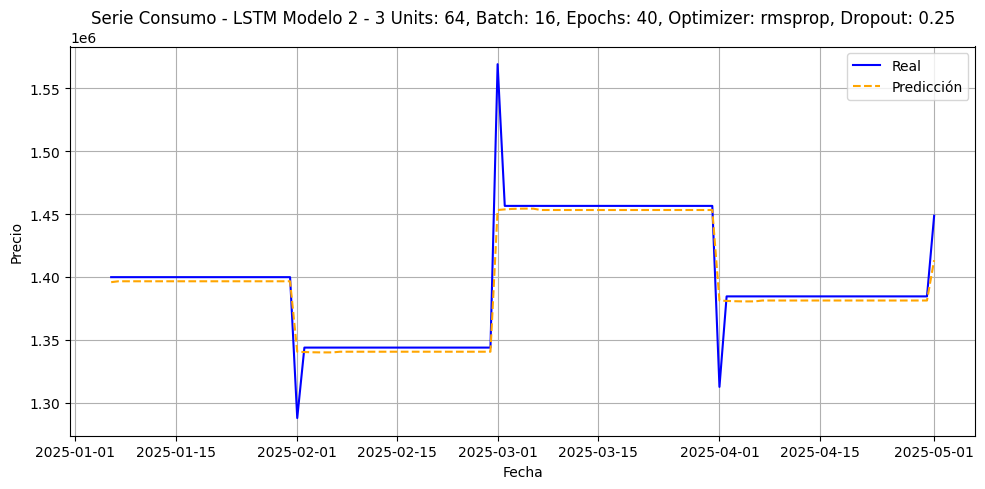


=== Modelo LSTM 2 - Configuración 4 ===
Units: 128, Batch: 32, Epochs: 60, Optimizer: adam, Dropout: 0.2


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


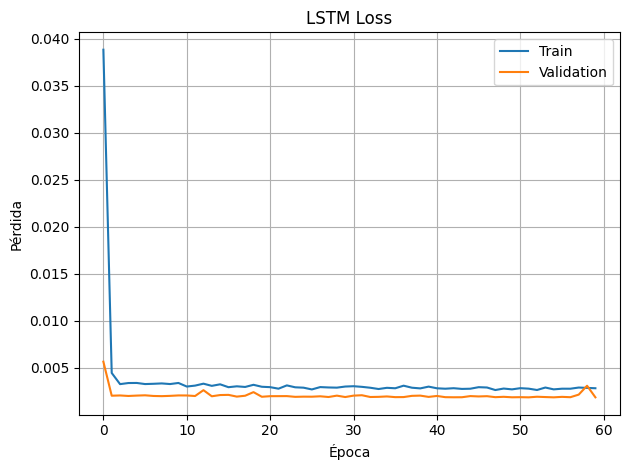

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
RMSE: 13906.5234
MAE: 3948.1410


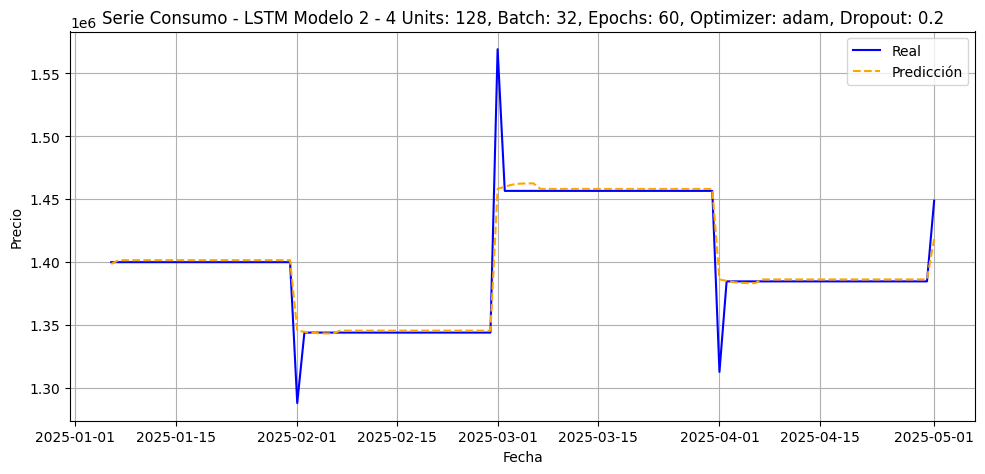

In [34]:
if SHOW_DL_S1:
    dl_metrics = {}

    for i, params in enumerate(param_grid, 1):
        print(f"\n=== Modelo {i} ===")
        print(f"Units: {params['units']}, Batch: {params['batch_size']}, Epochs: {params['epochs']}, Optimizer: {params['optimizer']}")
        
        model = buildLSTMModel1(n_lags=5, units=params["units"], optimizer=params["optimizer"])
        
        trainAndEvaluateLSTM(
            x_train, y_train,
            x_val, y_val,
            x_test, y_test,
            model,
            scaler,
            df_rango,
            n_lags=5,
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            name_model=f"Serie Consumo - LSTM Modelo 1 - {i} - Units: {params['units']}, Batch: {params['batch_size']}, Epochs: {params['epochs']}, Optimizer: {params['optimizer']}",
            metrics_dict=dl_metrics,
            save=SAVE_IMAGES,
            path=IMAGE_DIR
        )
        
        
    for i, params in enumerate(param_grid_model2, 1):
        print(f"\n=== Modelo LSTM 2 - Configuración {i} ===")
        print(f"Units: {params['units']}, Batch: {params['batch_size']}, Epochs: {params['epochs']}, "
            f"Optimizer: {params['optimizer']}, Dropout: {params['dropout']}")
        
        model = buildLSTMModel2(
            n_lags=5,
            units=params["units"],
            dropout_rate=params["dropout"],
            optimizer=params["optimizer"]
        )
        
        trainAndEvaluateLSTM(
            x_train, y_train,
            x_val, y_val,
            x_test, y_test,
            model,
            scaler,
            df_rango,
            n_lags=5,
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            name_model=f"Serie Consumo - LSTM Modelo 2 - {i} Units: {params['units']}, Batch: {params['batch_size']}, "
                    f"Epochs: {params['epochs']}, Optimizer: {params['optimizer']}, Dropout: {params['dropout']}",
            metrics_dict=dl_metrics,
            save=SAVE_IMAGES,
            path=IMAGE_DIR
        )

### Evaluación modelos de lab 1

X TEST: [[-1.40945465 -0.81156894  1.68939102 -0.33300168]]
X TEST SHAPE: (1, 4)


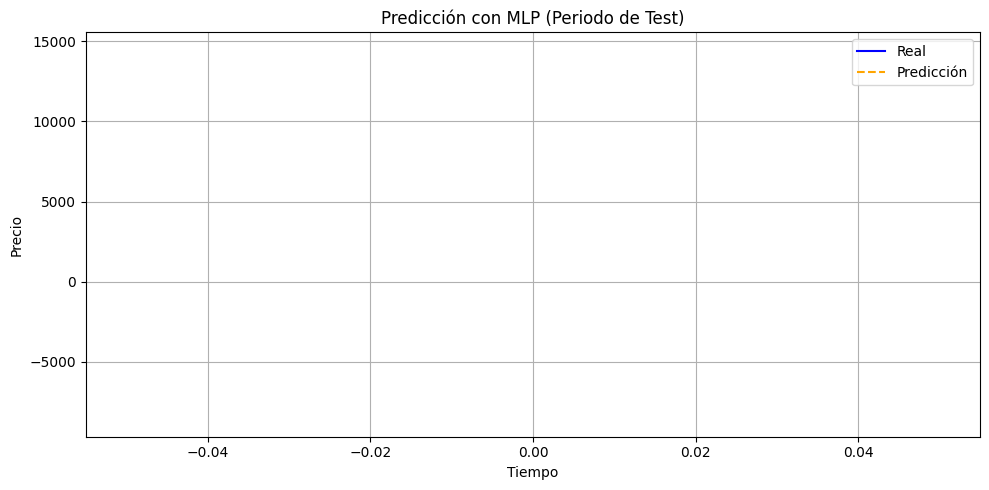

16:32:12 - cmdstanpy - INFO - Chain [1] start processing
16:32:12 - cmdstanpy - INFO - Chain [1] done processing


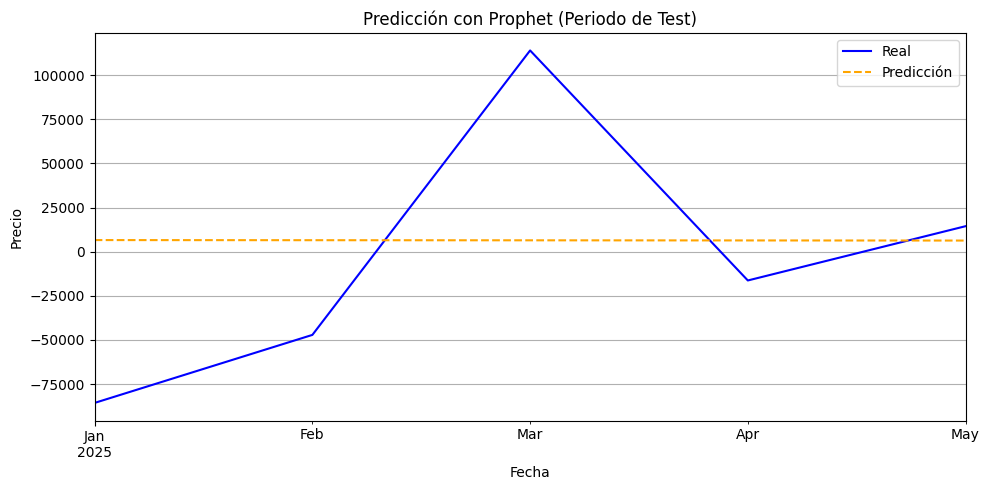

d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\prophet\plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()


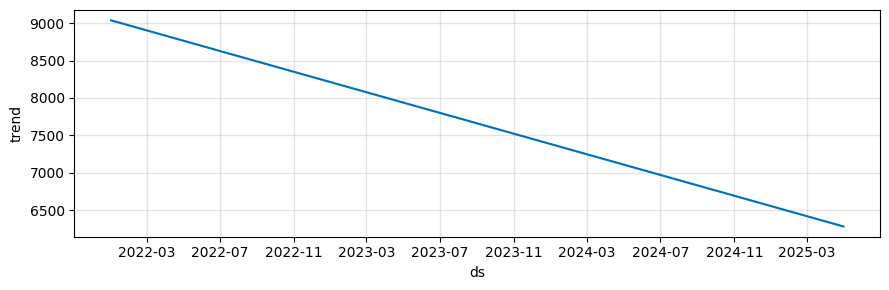

d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


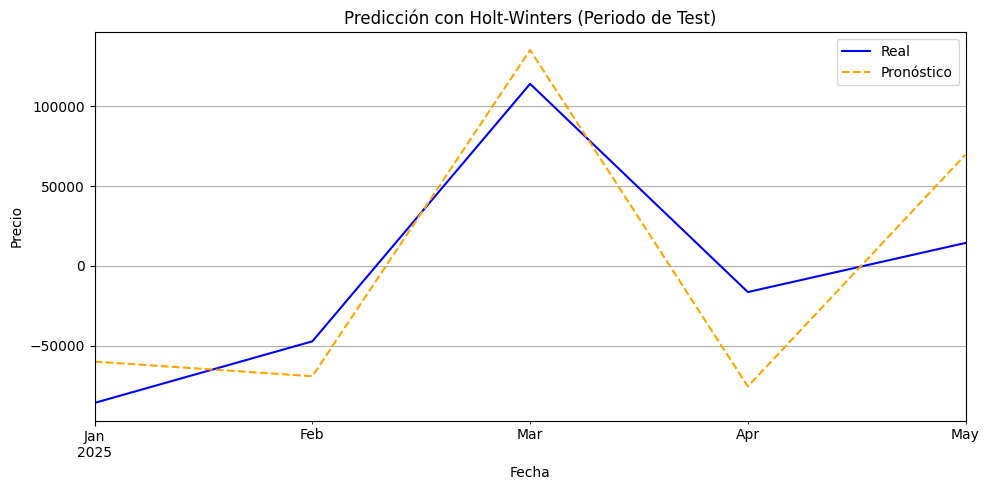

d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py

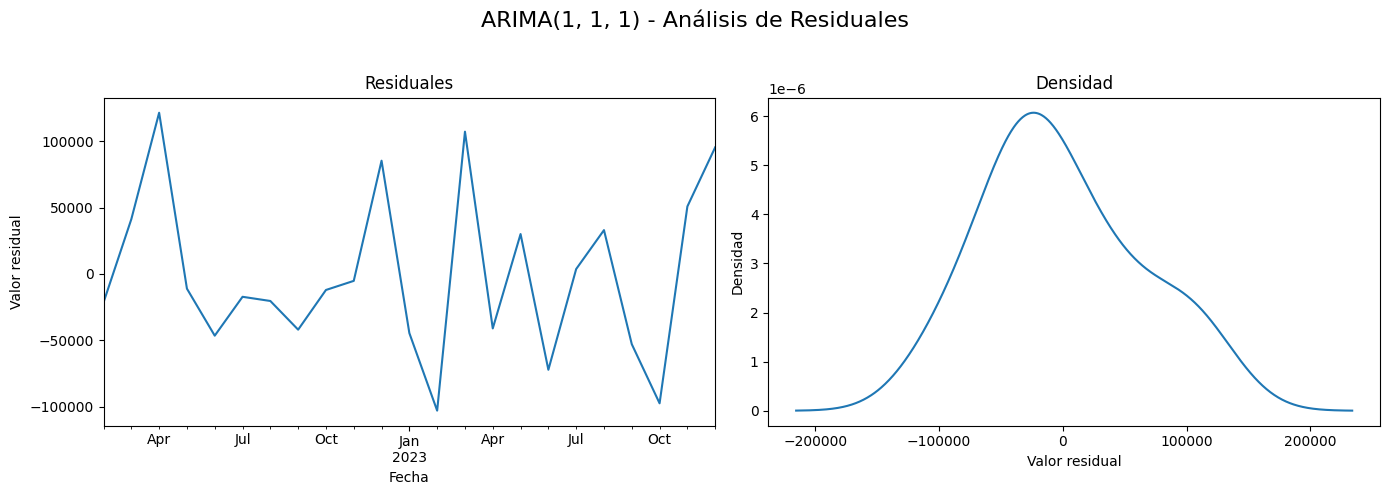

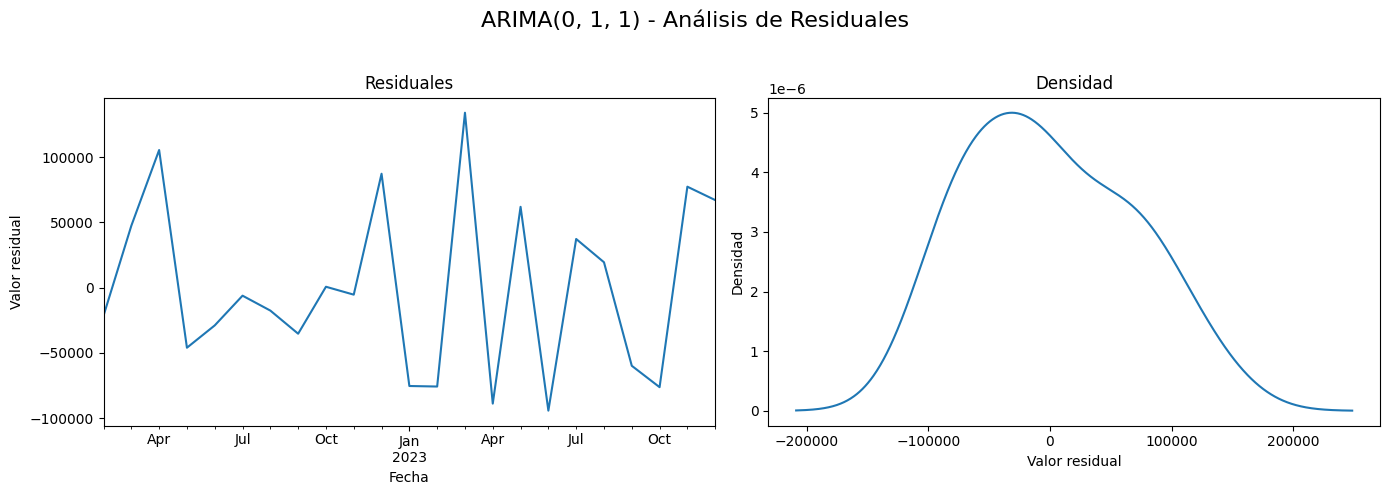

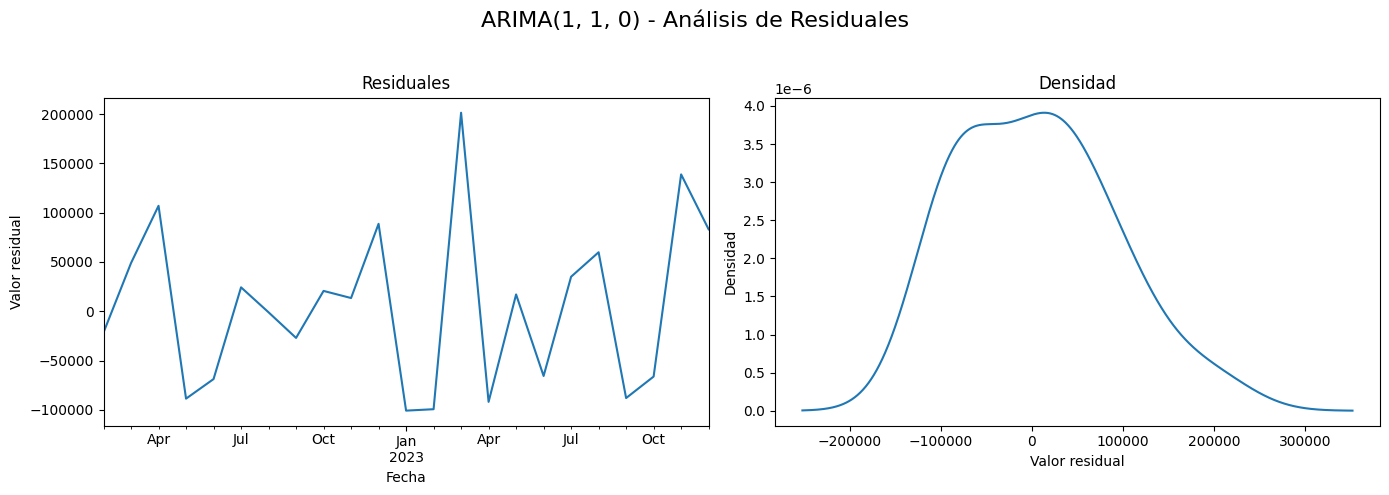

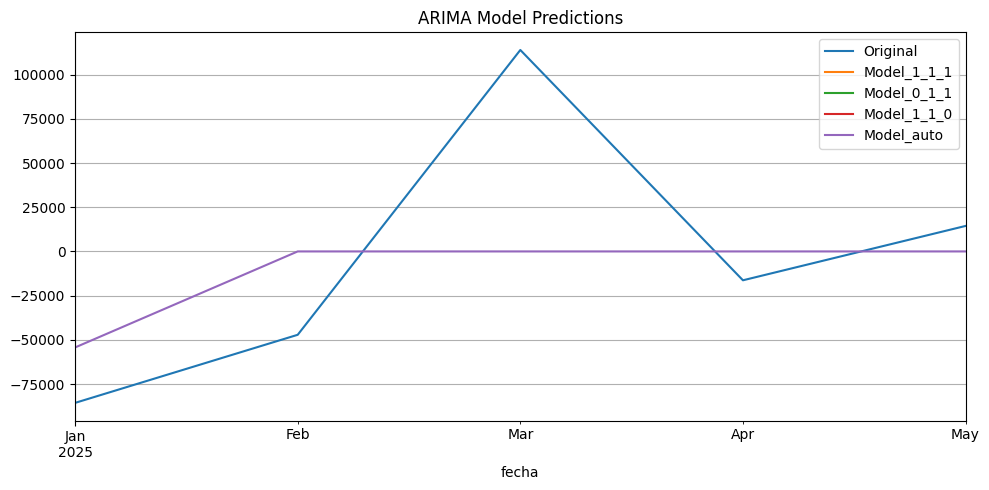

╒═══════════════════════════════════════════════════════════════════════════════════════════════════════╤══════════╤══════════╕
│ Modelo                                                                                                │     RMSE │      MAE │
╞═══════════════════════════════════════════════════════════════════════════════════════════════════════╪══════════╪══════════╡
│ MLP                                                                                                   │  22940.7 │ 22940.7  │
├───────────────────────────────────────────────────────────────────────────────────────────────────────┼──────────┼──────────┤
│ Prophet                                                                                               │  68595.3 │ 56841.8  │
├───────────────────────────────────────────────────────────────────────────────────────────────────────┼──────────┼──────────┤
│ Holt-Winters                                                                                          

In [35]:
if SHOW_RESULTS_LAB1:
    df = getRangeSerie(serie=df_consumo, initial_range="2022", column="regular", get_diff=True)
    train_data, val_data, test_data = splitSeriesByYears(df, train_until="2023", val_year="2024", test_year="2025")

    # División por años
    train_data, val_data, test_data = splitSeriesByYears(
        df,
        train_until="2023",
        val_year="2024",
        test_year="2025"
    )

    # Escalado
    scaler = StandardScaler()
    full_scaled = scaler.fit_transform(df.to_frame())
    train_scaled = full_scaled[:len(train_data)]
    val_scaled = full_scaled[len(train_data):len(train_data)+len(val_data)]
    test_scaled = full_scaled[-len(test_data):]

    # Ejecutar modelo MLP
    mlp_metrics = runMLPModel(
        train_scaled,
        val_scaled,
        test_scaled,
        scaler,
        n_lags=4,
        save=SAVE_IMAGES,
        path=IMAGE_DIR,
        reshape_x_test=False,
    )

    # Cantidad de días a predecir (según el tamaño del test real)
    forecast_steps = len(test_data)

    # Modelo Prophet
    forecast, model, prophet_metrics = runProphetModel(
        train_data,
        testData=test_data,
        save=SAVE_IMAGES,
        path=IMAGE_DIR
    )

    # Modelo Holt-Winters
    hw_forecast, hw_model, hw_metrics = runHoltWintersModel(
        trainData=train_data,
        testData=test_data,
        forecast_steps=forecast_steps,
        save=SAVE_IMAGES,
        path=IMAGE_DIR
    )

    # Entrenar modelos ARIMA con el set de entrenamiento
    arima_models = trainARIMAModels(train_data)
    model_orders = [(1, 1, 1), (0, 1, 1), (1, 1, 0)]

    # Analizar residuales de cada modelo
    for model, order in zip(arima_models, model_orders):
        titulo = f"ARIMA{order} - Análisis de Residuales"
        plotResiduals(model, titulo=titulo)

    # Evaluar modelos con el set de prueba
    arima_metrics = evaluateARIMAModels(
        models=arima_models,
        testData=test_data,
        save=SAVE_IMAGES,
        path=IMAGE_DIR + "/serie_consumos_arima_predictions.png"
    )
    
    mergeDisplayMetrics(arima_metrics, test_data, mlp_metrics, prophet_metrics, hw_metrics, dl_metrics)